In [5]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Secara garis besar, fungsionalitas dari library-library tersebut dapat dikelompokkan sebagai berikut:

* **Manipulasi Data dan Sistem Operasi (`os`, `numpy`, `pandas`):** Digunakan untuk berinteraksi dengan direktori komputer saat membaca berkas gambar, serta mengelola dan menstrukturkan data fitur gambar ke dalam bentuk matriks atau tabel (*dataframe*). Fungsi khusus seperti `sliding_window_view` digunakan untuk mengekstrak bagian-bagian kecil (patch) dari gambar secara efisien.
* **Pemrosesan Citra dan Ekstraksi Fitur (`cv2`, `skimage`, `scipy`):** OpenCV (`cv2`) bertugas untuk membaca dan memanipulasi gambar asli. Selanjutnya, `skimage.feature` (melalui GLCM atau *Gray-Level Co-occurrence Matrix*) dan `scipy.stats` (`entropy`) digunakan untuk mengekstrak karakteristik tekstur dan tingkat acak (entropi) dari gambar tersebut agar dapat dipahami oleh model komputer.
* **Machine Learning (`sklearn`):** Bertindak sebagai mesin kecerdasan buatan. Modul ini membagi data menjadi data latih dan data uji (`train_test_split`), lalu mengklasifikasikan tekstur gambar menggunakan tiga algoritma berbeda, yaitu **Random Forest**, **Support Vector Machine (SVC)**, dan **K-Nearest Neighbors (KNN)**.
* **Visualisasi dan Evaluasi Performa (`matplotlib`, `seaborn`, `sklearn.metrics`, `IPython`):** Setelah model selesai melakukan klasifikasi, kelompok *library* ini digunakan untuk menghitung tingkat akurasi, presisi, dan *recall*, serta menampilkan grafis berupa *Confusion Matrix* secara interaktif untuk melihat seberapa akurat model dalam menebak kelas gambar.

## Data Loading

Struktur folder dataset:
```
└──meat
    ├── FreshMeat
    │   ├── 0001.jpg
    │   ├── 0002.jpg
    │   └── ...
    └── RottenMeat
        ├── 0001.jpg
        ├── 0002.jpg
        └── ...
```

Kode di bawah ini digunakan untuk membaca dataset citra daging dari folder bernama `meat`, yang berisi subfolder sesuai dengan label kelas masing-masing. Untuk setiap subfolder, seluruh file gambar di dalamnya dibaca menggunakan OpenCV, kemudian dipastikan bertipe `uint8` dan dikonversi menjadi citra grayscale agar informasi warna disederhanakan menjadi satu kanal intensitas. Setiap citra yang berhasil dibaca disimpan ke dalam list `data`, nama subfolder (label kelas) disimpan ke dalam list `labels`, dan nama file gambar disimpan ke dalam list `file_name`. Setelah seluruh proses pembacaan selesai, ketiga list tersebut—`data` dan `labels` dikonversi menjadi array numpy agar lebih mudah diproses pada tahap selanjutnya.

In [6]:
data = []
labels = []
file_name = []
for sub_folder in os.listdir("meat\\"):
    sub_folder_files = os.listdir(os.path.join("meat\\", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("meat\\", sub_folder, filename)
        img = cv.imread(img_path)
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        
        data.append(img)
        labels.append(sub_folder)
        name = os.path.splitext(filename)[0]
        file_name.append(filename)
        
data = np.array(data)
labels = np.array(labels)

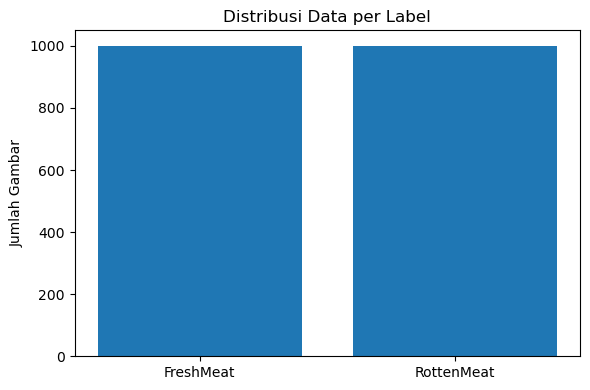

Jumlah total data: 2000
  FreshMeat: 1000 file
  RottenMeat: 1000 file


In [7]:
unique_labels, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(6, 4))
plt.bar(unique_labels, counts)
plt.ylabel("Jumlah Gambar")
plt.title("Distribusi Data per Label")
plt.tight_layout()
plt.show()

print("Jumlah total data:", len(labels))
for lab, c in zip(unique_labels, counts):
    print(f"  {lab}: {c} file")

## Data Preparation

### Define Preprocessing Function


In [8]:
def resize(image, target_size=(128, 128)):
    return cv.resize(image, target_size, interpolation=cv.INTER_AREA)

def clahe(img, clip_limit=2.0, grid_size=(8, 8)):        
    height, width = img.shape
    grid_h, grid_w = grid_size
    
    # Hitung ukuran per sub-gambar (tile)
    tile_h = height // grid_h
    tile_w = width // grid_w
    
    # Tempat menyimpan histogram kumulatif (CDF) untuk setiap tile
    # Ukurannya adalah (grid_h, grid_w, 256)
    tile_cdfs = np.zeros((grid_h, grid_w, 256))
    
    # TAHAP 1 & 2: Hitung Histogram, Kliping, dan Cari CDF untuk setiap Tile
    for i in range(grid_h):
        for j in range(grid_w):
            # Potong citra menjadi tile lokal
            y_start, y_end = i * tile_h, (i + 1) * tile_h
            x_start, x_end = j * tile_w, (j + 1) * tile_w
            tile = img[y_start:y_end, x_start:x_end]
            
            # Hitung histogram manual untuk tile saat ini
            hist, _ = np.histogram(tile.flatten(), bins=256, range=(0, 256))
            
            # Hitung batas kliping berdasarkan nilai clip_limit aktual
            # Rata-rata piksel per bin dikalikan dengan clip_limit parameter
            bin_pixels_avg = tile.size / 256
            actual_clip = clip_limit * bin_pixels_avg
            
            # Potong nilai histogram yang melebihi batas kliping
            excess = 0
            clipped_hist = hist.copy()
            for b in range(256):
                if clipped_hist[b] > actual_clip:
                    excess += clipped_hist[b] - actual_clip
                    clipped_hist[b] = actual_clip
            
            # Redistribusikan kelebihan piksel secara merata ke seluruh bin
            redist_amt = excess / 256
            clipped_hist = clipped_hist + redist_amt
            
            # Hitung CDF (Cumulative Distribution Function) dari histogram yang di-redistribusi
            cdf = clipped_hist.cumsum()
            
            # Normalisasi CDF agar rentangnya kembali menjadi 0-255
            cdf_min = cdf.min()
            cdf_max = cdf.max()
            if cdf_max - cdf_min > 0:
                cdf_normalized = ((cdf - cdf_min) / (cdf_max - cdf_min)) * 255
            else:
                cdf_normalized = cdf
                
            tile_cdfs[i, j] = cdf_normalized

    # TAHAP 3: Interpolasi Bilinear
    out_img = np.zeros_like(img, dtype=np.uint8)
    
    for y in range(height):
        for x in range(width):
            # Cari posisi relatif piksel terhadap pusat-pusat tile terdekat
            # Kurangi dengan setengah ukuran tile agar titik acuan ada di tengah tile
            v_pos = (y - tile_h / 2) / tile_h
            u_pos = (x - tile_w / 2) / tile_w
            
            # Cari indeks tile tetangga (kiri atas)
            tx = int(np.floor(u_pos))
            ty = int(np.floor(v_pos))
            
            # Hitung nilai delta untuk bobot interpolasi (0 sampai 1)
            delta_y = v_pos - ty
            delta_x = u_pos - tx
            
            # Batasi indeks agar tidak keluar dari grid
            tx = max(0, min(tx, grid_w - 2))
            ty = max(0, min(ty, grid_h - 2))
            
            val = img[y, x]
            
            # Ambil nilai pemetaan CDF dari 4 tile terdekat
            f00 = tile_cdfs[ty, tx, val]
            f10 = tile_cdfs[ty + 1, tx, val]
            f01 = tile_cdfs[ty, tx + 1, val]
            f11 = tile_cdfs[ty + 1, tx + 1, val]
            
            # Rumus Interpolasi Bilinear
            interpolated_val = (1 - delta_y) * ((1 - delta_x) * f00 + delta_x * f01) + \
                               delta_y * ((1 - delta_x) * f10 + delta_x * f11)
                               
            out_img[y, x] = np.clip(interpolated_val, 0, 255)
            
    return out_img

# MEDIAN BLUR
def filter_citra(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)
                    
                    canvas[i, j] = total_sum // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    # urutkan manual / manual sort (bubble sort)
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    # ambil nilai tengah / get middle value
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val
    # kembalikan gambar / return image
    return canvas

def show_samples(images, title):
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    fig.suptitle(title, fontsize=14)
    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap='gray')
        ax.axis('off')
    plt.show()

Fungsi `clahe` bekerja dengan membagi citra daging ke dalam beberapa sub-gambar kecil berbentuk ubin (**tile**) sesuai parameter `grid_size` (misal: $8 \times 8$ ubin). Pada setiap ubin, fungsi ini menghitung histogram lokal lalu memotong (**kliping**) puncak histogram yang melebihi batas (`clip_limit`) untuk mencegah kontras yang berlebihan. Kelebihan piksel tersebut kemudian didistribusikan kembali secara merata ke seluruh *bin* histogram sebelum diubah menjadi fungsi distribusi kumulatif (**CDF**) yang ternormalisasi. Terakhir, untuk menghindari efek patahan atau batas kotak yang kasar antar-ubin, fungsi ini memetakan kembali nilai piksel asli menggunakan **Interpolasi Bilinear** dari 4 ubin tetangga terdekat, sehingga menghasilkan transisi kontras lokal yang halus dan natural.

Fungsi `filter_citra` mendefinisikan area pemrosesan dengan membuat tepian tambahan (**padding**) di sekeliling citra asli menggunakan metode piksel duplikat (`mode='edge'`) agar piksel di bagian ujung luar tetap bisa diproses. Fungsi kemudian menggeser jendela matriks (**kernel**) berukuran `size` secara berurutan piksel demi piksel di seluruh citra. Pada setiap posisi jendela, seluruh nilai piksel di dalam cakupan kernel dikumpulkan ke dalam sebuah daftar, lalu diurutkan secara manual dari nilai terkecil hingga terbesar menggunakan algoritma *bubble sort*. Nilai tengah (**median**) dari daftar yang sudah terurut tersebut diambil untuk menggantikan nilai piksel pusat di kanvas hasil, yang secara efektif mampu mengeliminasi *noise* bintik tajam tanpa mengaburkan garis tepi serat daging.

### Preprocessing

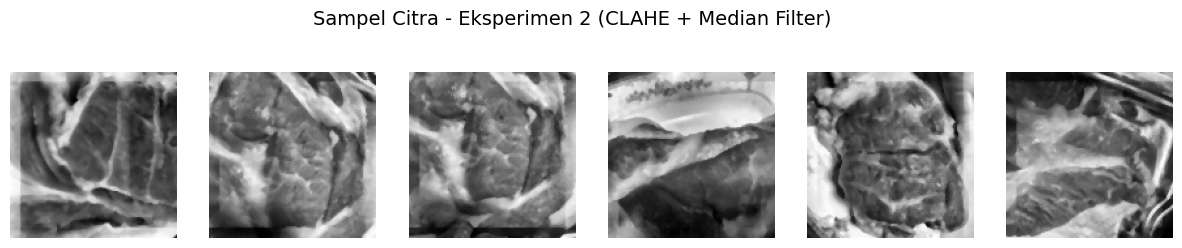

Total citra yang siap diekstrak GLCM: 2000


In [9]:
dataPreprocessed = []
for i in range(len(data)): 
    # Karena data di awal sudah diubah ke grayscale saat di-load, cukup memasukkannya langsung ke dalam dataPreprocessed
    img_processed = data[i]
    img_resize = resize(img_processed)
    img_clahe = clahe(img_resize)
    img_median = filter_citra(img_clahe, 3, 'median')
    # Masukkan ke dalam list agar tidak kosong
    dataPreprocessed.append(img_median)

show_samples(dataPreprocessed[:6], "Sampel Citra - Eksperimen 2 (CLAHE + Median Filter)")
print("Total citra yang siap diekstrak GLCM:", len(dataPreprocessed))

### Feature Extraction

In [10]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Kode di atas mendefinisikan fungsi `glcm` untuk menghitung *Gray-Level Co-occurrence Matrix* (GLCM) dari citra grayscale berdasarkan sudut tertentu (0, 45, 90, atau 135 derajat). Fungsi menerima input citra dan derajat sudut, kemudian mengonversi sudut tersebut ke radian yang diperlukan oleh fungsi `graycomatrix` dari library `skimage.feature`. GLCM dihitung dengan jarak piksel 1, diatur agar simetris dan ternormalisasi. Matriks GLCM ini sangat berguna untuk ekstraksi fitur tekstur pada tahap selanjutnya.

**Alasan pemilihan metode:** GLCM dipilih sebagai metode ekstraksi fitur karena klasifikasi citra daging segar dan busuk pada dasarnya lebih ditentukan oleh karakteristik tekstur permukaan (kasar, halus, berserat, berlendir, dsb) dibandingkan oleh bentuk objek atau warna semata. GLCM menangkap hubungan statistik antara pasangan piksel yang bertetangga pada jarak dan arah tertentu, sehingga mampu merepresentasikan pola tekstur tersebut secara kuantitatif. Penggunaan empat arah sudut (0°, 45°, 90°, 135°) bertujuan agar tekstur yang mungkin tidak seragam ke segala arah (anisotropik) tetap dapat tertangkap secara lebih lengkap, dibandingkan hanya menggunakan satu arah saja.

In [11]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

Kode di atas mendefinisikan fungsi `correlation` yang digunakan untuk mengekstrak fitur korelasi dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi memanfaatkan `graycoprops` dari library `skimage.feature` dengan parameter `'correlation'` untuk menghitung tingkat korelasi antar piksel dalam citra berdasarkan GLCM yang diberikan. Nilai korelasi ini menggambarkan hubungan linier antara intensitas piksel yang berdekatan dan dapat menjadi fitur penting dalam membedakan tekstur antar kelas citra daging.

In [12]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

Kode di atas mendefinisikan fungsi `dissimilarity` untuk mengambil fitur dissimilarity dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `graycoprops` dari `skimage.feature` dengan parameter `'dissimilarity'` untuk mengukur seberapa berbeda intensitas piksel yang berdekatan dalam citra. Nilai dissimilarity ini membantu dalam menangkap variasi tekstur dan perbedaan lokal pada citra, yang berguna untuk proses klasifikasi citra.

In [13]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

Kode di atas mendefinisikan fungsi `homogenity` yang digunakan untuk mengekstrak fitur homogeneity dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi memanfaatkan `graycoprops` dari library `skimage.feature` dengan parameter `'homogeneity'` untuk mengukur seberapa seragam tekstur dalam citra, yaitu seberapa dekat distribusi elemen dalam GLCM ke diagonal utamanya. Nilai homogeneity yang tinggi menunjukkan tekstur yang lebih seragam, yang dapat membantu membedakan karakteristik tekstur antar kelas citra daging.

In [14]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

Kode di atas mendefinisikan fungsi `contrast` untuk mengekstrak fitur contrast dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `graycoprops` dari `skimage.feature` dengan parameter `'contrast'` untuk mengukur perbedaan intensitas lokal dalam citra. Nilai contrast yang tinggi menunjukkan adanya variasi tekstur yang kuat, sehingga fitur ini berguna untuk membedakan pola dan tekstur pada citra dalam proses klasifikasi.

In [15]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

Kode di atas mendefinisikan fungsi `ASM` untuk mengekstrak fitur Angular Second Moment (ASM) dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `graycoprops` dari `skimage.feature` dengan parameter `'ASM'`, yang mengukur tingkat keseragaman atau energi tekstur dalam citra. Nilai ASM yang tinggi menunjukkan tekstur yang lebih homogen dan teratur, sehingga fitur ini membantu dalam analisis dan klasifikasi pola tekstur citra daging.

In [16]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

Kode di atas mendefinisikan fungsi `energy` yang digunakan untuk mengekstrak fitur energy dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi memanfaatkan `graycoprops` dari library `skimage.feature` dengan parameter `'energy'`, yang merupakan akar kuadrat dari Angular Second Moment (ASM) dan mencerminkan keseragaman tekstur dalam citra. Nilai energy yang tinggi menunjukkan tekstur yang lebih konsisten dan beraturan, sehingga fitur ini penting untuk proses klasifikasi.

In [17]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Kode di atas mendefinisikan fungsi `entropyGlcm` untuk menghitung fitur entropy dari matriks GLCM (Gray-Level Co-occurrence Matrix). Fungsi menggunakan `entropy` dari modul `scipy.stats` pada matriks GLCM yang telah diratakan (dirubah menjadi vektor satu dimensi) untuk mengukur tingkat ketidakteraturan atau kompleksitas tekstur citra. Nilai entropy yang tinggi menunjukkan tekstur yang lebih acak dan tidak teratur, sehingga fitur ini membantu dalam membedakan karakteristik tekstur antar kelas citra.

## Ekstraksi GLCM pada Berbagai Derajat

In [18]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kode di atas melakukan ekstraksi Gray-Level Co-occurrence Matrix (GLCM) dari setiap citra dalam `dataPreprocessed` pada empat arah sudut yang berbeda: 0°, 45°, 90°, dan 135°. Dengan menggunakan fungsi `glcm`, setiap citra diproses untuk menghasilkan matriks GLCM pada masing-masing derajat tersebut, yang kemudian disimpan dalam list terpisah (`Derajat0`, `Derajat45`, `Derajat90`, `Derajat135`). Ekstraksi pada berbagai arah ini berguna untuk menangkap tekstur citra secara lebih menyeluruh, karena pola tekstur dapat bervariasi tergantung arah pengamatannya.

## Inisialisasi Variabel untuk Fitur GLCM

In [19]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


Kode di atas membuat beberapa list kosong untuk menyimpan nilai fitur tekstur yang diekstrak dari matriks GLCM pada masing-masing sudut 0°, 45°, 90°, dan 135°. Fitur-fitur tersebut meliputi kontras (contrast), dissimilarity, homogenitas (homogeneity), entropi (entropy), angular second moment (ASM), energi (energy), dan korelasi (correlation). Setiap fitur memiliki empat list terpisah sesuai dengan arah ekstraksi GLCM, yang nantinya akan diisi dengan nilai-nilai hasil ekstraksi pada cell-cell berikutnya.

## Ekstraksi Fitur Korelasi dari GLCM pada Berbagai Derajat

In [20]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

Kode di atas menghitung nilai fitur korelasi (correlation) dari matriks GLCM yang sudah diekstraksi pada empat sudut berbeda (0°, 45°, 90°, dan 135°) untuk setiap citra dalam `dataPreprocessed`. Fungsi `correlation()` digunakan untuk mengambil nilai korelasi dari masing-masing matriks GLCM, kemudian hasilnya disimpan ke dalam list yang sesuai (`correlation0`, `correlation45`, `correlation90`, `correlation135`).

## Ekstraksi Fitur Kontras dari GLCM pada Berbagai Derajat

In [21]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

Kode di atas melakukan perhitungan nilai fitur kontras (contrast) dari matriks GLCM yang telah diekstraksi pada sudut 0°, 45°, 90°, dan 135° untuk setiap citra. Fungsi `contrast()` digunakan untuk memperoleh nilai kontras dari masing-masing matriks GLCM, kemudian nilai-nilai tersebut disimpan dalam list terpisah (`Kontras0`, `Kontras45`, `Kontras90`, dan `Kontras135`). Perlu diperhatikan bahwa perulangan pada cell ini menggunakan `len(data)` sebagai acuan jumlah iterasi, bukan `len(dataPreprocessed)` seperti pada cell ekstraksi GLCM sebelumnya, sehingga jumlah iterasi akan tetap konsisten selama panjang `data` dan `dataPreprocessed` sama.

## Ekstraksi Fitur Dissimilarity dari GLCM pada Berbagai Derajat

In [22]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

Kode di atas mengekstrak nilai fitur dissimilarity dari matriks GLCM yang dihasilkan pada sudut 0°, 45°, 90°, dan 135° untuk setiap citra. Fungsi `dissimilarity()` digunakan untuk menghitung tingkat perbedaan intensitas antar piksel pada citra, kemudian hasilnya disimpan dalam list terpisah (`dissimilarity0`, `dissimilarity45`, `dissimilarity90`, dan `dissimilarity135`).

## Ekstraksi Fitur Homogeneity dari GLCM pada Berbagai Derajat

In [23]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

Kode di atas melakukan ekstraksi fitur homogeneity dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. Fungsi `homogenity()` digunakan untuk mengukur keseragaman atau tingkat kemiripan intensitas piksel yang berdekatan, dan hasilnya disimpan dalam list `homogenity0`, `homogenity45`, `homogenity90`, dan `homogenity135`.

## Ekstraksi Fitur Entropy dari GLCM pada Berbagai Derajat

In [24]:
for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

Kode di atas mengekstrak fitur entropy dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. Fungsi `entropyGlcm()` menghitung entropi, yaitu ukuran ketidakteraturan atau kompleksitas tekstur citra, dari nilai-nilai matriks GLCM yang diratakan. Nilai entropy ini kemudian disimpan dalam list `entropy0`, `entropy45`, `entropy90`, dan `entropy135`.

## Ekstraksi Fitur ASM (Angular Second Moment) dari GLCM pada Berbagai Derajat

In [25]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

Kode di atas menghitung fitur Angular Second Moment (ASM) dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. ASM adalah ukuran homogenitas tekstur yang tinggi, menunjukkan seberapa seragam pola tekstur pada citra. Nilai ASM dari setiap derajat disimpan ke dalam list `ASM0`, `ASM45`, `ASM90`, dan `ASM135`.

## Ekstraksi Fitur Energy dari GLCM pada Berbagai Derajat

In [26]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

Kode di atas menghitung fitur Energy dari matriks GLCM untuk sudut 0°, 45°, 90°, dan 135° pada setiap citra. Energy merupakan akar kuadrat dari ASM dan mengukur kekompakan atau keteraturan tekstur dalam citra. Nilai energy untuk tiap derajat disimpan dalam list `energy0`, `energy45`, `energy90`, dan `energy135`.

### Write the extraction's results to CSV 

In [27]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_2.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0001.jpg,FreshMeat,129.398684,248.848286,151.885089,265.524521,0.261061,0.203704,0.274134,0.187784,...,0.000497,0.000300,0.021399,0.018489,0.022305,0.017319,0.972224,0.945851,0.967273,0.942216
1,0002.jpg,FreshMeat,173.928949,219.142662,152.669045,325.049538,0.257578,0.208015,0.266749,0.180001,...,0.000415,0.000249,0.019436,0.016939,0.020380,0.015795,0.956971,0.945364,0.962190,0.918963
2,0003.jpg,FreshMeat,136.515625,249.330523,154.536171,257.234360,0.267261,0.197898,0.264470,0.190514,...,0.000408,0.000266,0.020413,0.016632,0.020188,0.016297,0.965128,0.936034,0.960585,0.934013
3,0004.jpg,FreshMeat,71.941006,251.154318,168.244587,173.877736,0.353147,0.222749,0.284873,0.249787,...,0.000358,0.000297,0.022147,0.016310,0.018925,0.017241,0.990020,0.965050,0.976545,0.975800
4,0005.jpg,FreshMeat,245.385581,338.100874,222.451526,470.874884,0.238030,0.184936,0.271622,0.164300,...,0.000359,0.000192,0.017300,0.014802,0.018936,0.013864,0.962346,0.947860,0.965983,0.927394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0996.jpg,RottenMeat,508.374077,771.550685,327.663201,738.984624,0.250562,0.157204,0.257698,0.163343,...,0.000292,0.000167,0.017357,0.012717,0.017079,0.012927,0.934234,0.899805,0.957644,0.904029
1996,0997.jpg,RottenMeat,323.537648,781.483787,564.617434,812.692851,0.250337,0.146077,0.217474,0.145653,...,0.000234,0.000144,0.016955,0.012060,0.015294,0.012016,0.949758,0.877506,0.911855,0.872601
1997,0998.jpg,RottenMeat,573.485913,803.143530,305.594980,772.740777,0.220038,0.145749,0.258874,0.151377,...,0.000299,0.000150,0.015415,0.012079,0.017304,0.012231,0.911219,0.875061,0.952905,0.879785
1998,0999.jpg,RottenMeat,479.358268,691.803522,385.740281,800.118730,0.222560,0.154517,0.213694,0.142068,...,0.000215,0.000135,0.015153,0.012088,0.014674,0.011640,0.930925,0.900019,0.944544,0.884387


Kode di atas menggabungkan seluruh fitur tekstur hasil ekstraksi GLCM dari berbagai derajat (0°, 45°, 90°, 135°) beserta label dan nama file gambar ke dalam sebuah dictionary bernama `dataTable`. Dictionary ini kemudian diubah menjadi DataFrame menggunakan pandas dan disimpan ke file CSV bernama `'hasil_ekstraksi_2.csv'`. Selanjutnya, file CSV tersebut dibaca kembali ke dalam variabel `hasilEkstrak` untuk memastikan data tersimpan dengan benar dan siap digunakan pada tahap seleksi fitur.

### Features Selection

Kode di bawah ini melakukan seleksi fitur menggunakan pendekatan korelasi antar fitur. Pertama, dihitung matriks korelasi antar seluruh kolom fitur pada `hasilEkstrak` (setelah kolom `Label` dan `Filename` dihapus). Selanjutnya, ditentukan sebuah `threshold` (di sini diatur sebesar 0.95) sebagai batas korelasi absolut antar dua fitur; apabila korelasi antara dua fitur melebihi batas tersebut, salah satu dari kedua fitur tersebut akan ditandai untuk dihapus (`columns[j] = False`) karena dianggap membawa informasi yang redundan. Fitur-fitur yang tersisa setelah penyaringan ini disimpan dalam `select`, dan digunakan untuk membentuk dataset fitur baru `x_new`, sementara label kelas disimpan dalam `y`. Sebagai langkah verifikasi, hasil korelasi antar fitur yang tersisa divisualisasikan menggunakan heatmap dari `seaborn` agar lebih mudah diamati apakah masih terdapat fitur dengan korelasi tinggi setelah proses penyaringan.

**Alasan pemilihan metode:** Karena fitur GLCM diekstraksi pada empat arah sudut (0°, 45°, 90°, 135°) untuk tujuh jenis fitur tekstur, total terdapat 28 kolom fitur yang berpotensi banyak mengandung redundansi, misalnya nilai contrast pada sudut 0° dan 45° kemungkinan besar berkorelasi tinggi karena berasal dari citra yang sama. Pendekatan korelasi dipilih karena sederhana, cepat dihitung, dan langsung dapat mengidentifikasi pasangan fitur yang hampir membawa informasi yang sama (redundan) tanpa perlu melibatkan label kelas. Dengan menghapus salah satu fitur dari setiap pasangan yang berkorelasi tinggi, dimensi data dapat dikurangi sehingga model klasifikasi menjadi lebih ringan dan berpotensi mengurangi risiko overfitting akibat fitur yang terlalu banyak dan saling tumpang tindih.

<Axes: >

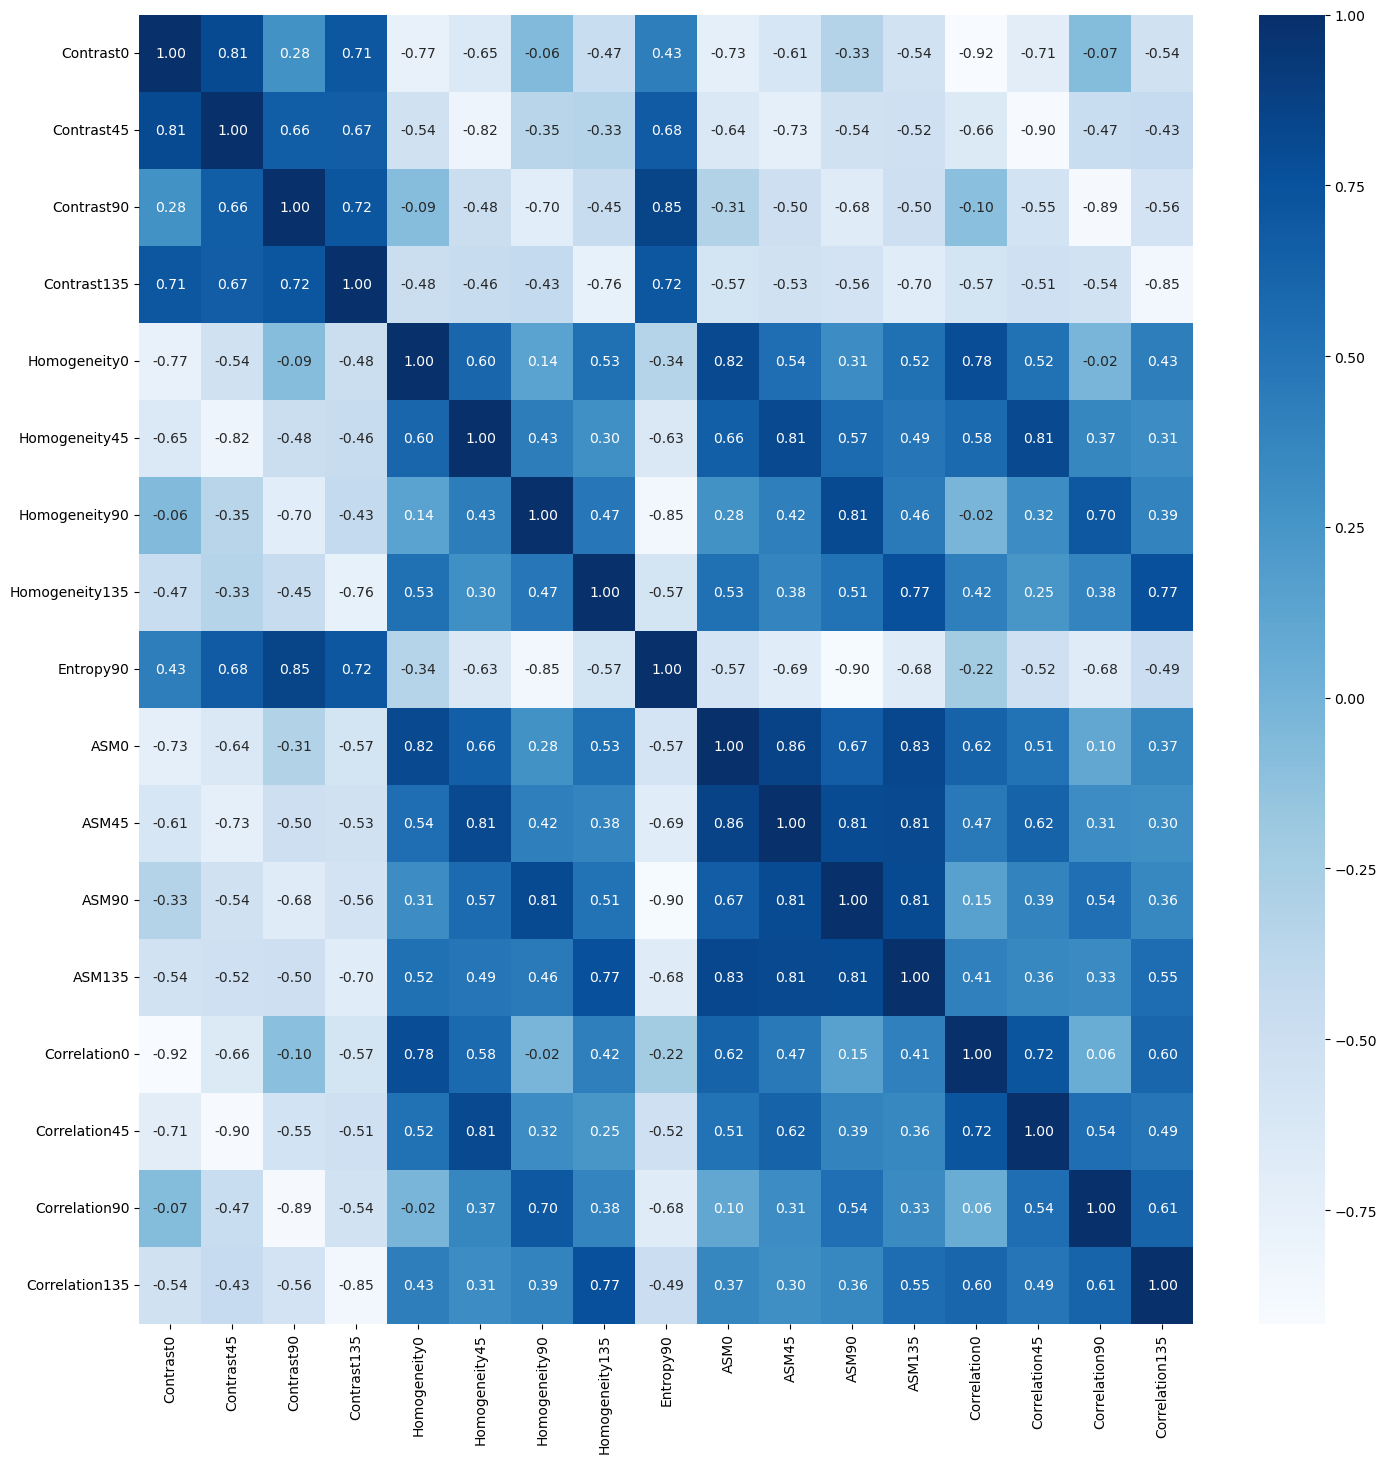

In [28]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

## Splitting Data

In [29]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(1600, 17)
(400, 17)


Kode di atas melakukan pembagian dataset fitur (`x_new`) dan label (`y`) menjadi data pelatihan (train) dan pengujian (test) menggunakan fungsi `train_test_split` dari scikit-learn. Parameter `test_size=0.2` menunjukkan bahwa 20% data dialokasikan untuk testing, sedangkan 80% sisanya untuk training. Pengaturan `random_state=42` digunakan agar pembagian data ini konsisten dan dapat direproduksi. Setelah pembagian, kode mencetak bentuk (shape) dari dataset train dan test untuk memastikan proporsi pembagian data sudah sesuai yang diharapkan.

## Feature Normalization

Kode di bawah ini melakukan normalisasi fitur pada data train dan test menggunakan metode standardisasi (z-score normalization). Data train dinormalisasi dengan mengurangi nilai rata-rata (`mean`) dan membagi dengan standar deviasi (`std`) dari data train itu sendiri, agar fitur memiliki distribusi dengan rata-rata 0 dan standar deviasi 1. Data test juga dinormalisasi menggunakan mean dan std yang sama dari data train (bukan dari data test) agar skala kedua dataset konsisten dan tidak terjadi kebocoran informasi (data leakage) dari data test ke proses normalisasi.

**Alasan pemilihan metode:** Fitur-fitur tekstur GLCM (contrast, homogeneity, energy, entropy, dsb) memiliki rentang nilai yang sangat berbeda satu sama lain, misalnya entropy dapat bernilai jauh lebih besar dibandingkan correlation yang berada pada rentang -1 hingga 1. Standardisasi (z-score) dipilih karena menyetarakan skala seluruh fitur ke distribusi dengan rata-rata 0 dan standar deviasi 1, sehingga tidak ada satu fitur pun yang mendominasi proses pembelajaran model hanya karena rentang nilainya lebih besar. Hal ini penting terutama untuk algoritma seperti SVM dan KNN yang sangat sensitif terhadap skala fitur, karena kedua algoritma tersebut mengandalkan perhitungan jarak atau margin antar titik data.

In [30]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

### Define Model

Kode di bawah ini mendefinisikan fungsi `generateClassificationReport` untuk mencetak laporan evaluasi model klasifikasi yang mencakup classification report (precision, recall, f1-score), confusion matrix, dan akurasi. Selain itu, tiga algoritma klasifikasi didefinisikan: Random Forest dengan 5 pohon keputusan (`n_estimators=5`), Support Vector Machine (SVM) dengan kernel RBF, dan K-Nearest Neighbors (KNN) dengan 5 tetangga (`n_neighbors=5`). Ketiga model ini akan digunakan dan dibandingkan performanya pada tahap pelatihan dan evaluasi selanjutnya.

**Alasan pemilihan ketiga algoritma:** Random Forest, SVM, dan KNN dipilih karena ketiganya merepresentasikan tiga pendekatan klasifikasi yang berbeda secara fundamental, sehingga perbandingan di antara ketiganya dapat memberikan gambaran metode mana yang paling cocok untuk karakteristik fitur tekstur GLCM pada dataset citra daging ini. Random Forest mewakili pendekatan berbasis ensemble pohon keputusan yang membagi ruang fitur berdasarkan aturan threshold pada tiap fitur secara bertahap, SVM mewakili pendekatan berbasis margin yang mencari batas pemisah optimal antar kelas, dan KNN mewakili pendekatan berbasis kemiripan (instance-based) yang mengklasifikasikan data baru berdasarkan kedekatannya dengan data latih. Ketiga algoritma ini juga relatif ringan secara komputasi dan cocok digunakan pada dataset berukuran kecil hingga menengah seperti pada eksperimen ini, di mana jumlah fitur sudah direduksi melalui tahap feature selection sebelumnya.

In [31]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

Kode di bawah ini melatih model Random Forest menggunakan data latih (`X_train`, `y_train`). Setelah pelatihan selesai, model digunakan untuk melakukan prediksi pada data latih dan data uji (`X_test`). Hasil prediksi tersebut kemudian dievaluasi dengan fungsi `generateClassificationReport` yang menampilkan classification report, confusion matrix, dan akurasi untuk kedua set data. Tujuan dari langkah ini adalah untuk mengetahui seberapa baik model dapat mengklasifikasikan data latih maupun data yang belum pernah dilihat sebelumnya, serta untuk mendeteksi indikasi overfitting apabila akurasi pada data latih jauh lebih tinggi dibandingkan data uji.

**Analisis algoritma Random Forest:** Random Forest bekerja dengan membangun banyak pohon keputusan (decision tree) secara independen, di mana setiap pohon dilatih menggunakan sub-sampel data dan sub-set fitur yang dipilih secara acak (bagging), kemudian hasil prediksi akhirnya diambil melalui voting mayoritas dari seluruh pohon. Pada eksperimen ini, jumlah pohon yang digunakan relatif sedikit (`n_estimators=5`), sehingga keragaman antar pohon menjadi terbatas dan performa model sangat bergantung pada kualitas masing-masing pohon individu; jumlah pohon yang lebih besar umumnya dapat meningkatkan stabilitas dan akurasi prediksi karena variansi model semakin berkurang. Kelebihan Random Forest adalah kemampuannya menangani fitur yang tidak perlu dinormalisasi secara ketat dan relatif tahan terhadap overfitting dibandingkan satu pohon keputusan tunggal, namun karena jumlah pohon yang sedikit pada kode ini, model masih berpotensi kurang stabil terutama jika data latih berjumlah kecil seperti pada kasus klasifikasi citra daging ini.

In [32]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

   FreshMeat       0.99      0.99      0.99       801
  RottenMeat       0.99      0.99      0.99       799

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600

[[796   5]
 [  4 795]]
Accuracy: 0.994375

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.94      0.90      0.92       199
  RottenMeat       0.90      0.95      0.92       201

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400

[[179  20]
 [ 11 190]]
Accuracy: 0.9225


### Train SVM Classifier

Kode di bawah ini melatih model Support Vector Machine (SVM) dengan kernel RBF menggunakan data latih (`X_train`, `y_train`). Setelah model dilatih, prediksi dilakukan pada data latih dan data uji (`X_test`). Fungsi `generateClassificationReport` digunakan untuk menampilkan metrik evaluasi seperti classification report, confusion matrix, dan akurasi pada kedua set data. Langkah ini bertujuan mengukur performa model SVM dalam mengklasifikasikan citra daging berdasarkan fitur tekstur GLCM yang telah diekstraksi dan diseleksi sebelumnya.

**Analisis algoritma SVM:** SVM bekerja dengan mencari hyperplane (bidang pemisah) yang memaksimalkan margin antara dua kelas pada ruang fitur, dan dengan menggunakan kernel RBF (Radial Basis Function), SVM mampu memetakan data ke ruang dimensi yang lebih tinggi sehingga dapat memisahkan kelas yang tidak dapat dipisahkan secara linear pada ruang fitur aslinya. Pendekatan ini cocok diterapkan pada fitur GLCM yang telah dinormalisasi menggunakan z-score, karena SVM dengan kernel RBF sangat sensitif terhadap skala fitur—fitur yang tidak ternormalisasi dapat menyebabkan margin yang terbentuk menjadi bias terhadap fitur dengan rentang nilai yang lebih besar. SVM umumnya bekerja baik pada dataset dengan jumlah fitur yang relatif sedikit namun informatif (seperti hasil seleksi fitur korelasi pada eksperimen ini), serta cenderung lebih tahan terhadap overfitting dibandingkan model yang lebih kompleks apabila jumlah data latih terbatas.

In [33]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

   FreshMeat       0.95      0.94      0.95       801
  RottenMeat       0.94      0.95      0.95       799

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600

[[756  45]
 [ 37 762]]
Accuracy: 0.94875

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.94      0.90      0.92       199
  RottenMeat       0.91      0.94      0.92       201

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400

[[180  19]
 [ 12 189]]
Accuracy: 0.9225


### Train KNN Classifier

Kode di bawah ini melatih model K-Nearest Neighbors (KNN) dengan `k=5` menggunakan data latih (`X_train`, `y_train`). Setelah pelatihan selesai, model melakukan prediksi pada data latih dan data uji (`X_test`). Fungsi `generateClassificationReport` kemudian digunakan untuk menampilkan hasil evaluasi berupa classification report, confusion matrix, dan akurasi untuk kedua set data tersebut. Proses ini bertujuan untuk menilai kemampuan model KNN dalam mengklasifikasikan fitur tekstur citra daging berdasarkan jarak terhadap tetangga terdekatnya.

**Analisis algoritma KNN:** KNN merupakan algoritma berbasis instance (instance-based learning) yang tidak membangun model eksplisit pada saat pelatihan, melainkan menyimpan seluruh data latih dan melakukan klasifikasi pada saat prediksi dengan menghitung jarak (umumnya jarak Euclidean) antara data baru dan seluruh data latih, kemudian menentukan kelas berdasarkan mayoritas label dari `k=5` tetangga terdekat. Karena KNN sangat bergantung pada perhitungan jarak antar titik data, normalisasi z-score yang dilakukan sebelumnya menjadi krusial agar setiap fitur GLCM memberikan kontribusi yang seimbang terhadap perhitungan jarak, tanpa normalisasi tersebut fitur dengan rentang nilai besar akan mendominasi hasil perhitungan jarak. Kelemahan utama KNN adalah biaya komputasi pada saat prediksi yang meningkat seiring jumlah data latih, serta sensitivitasnya terhadap pemilihan nilai `k`—nilai `k` yang terlalu kecil dapat membuat model rentan terhadap noise, sedangkan nilai `k` yang terlalu besar dapat membuat batas antar kelas menjadi terlalu halus dan mengabaikan pola lokal pada data.

In [34]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
              precision    recall  f1-score   support

   FreshMeat       0.98      0.95      0.96       801
  RottenMeat       0.95      0.98      0.96       799

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600

[[760  41]
 [ 19 780]]
Accuracy: 0.9625

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.95      0.89      0.92       199
  RottenMeat       0.90      0.96      0.93       201

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400

[[177  22]
 [  9 192]]
Accuracy: 0.9225


## Evaluation With Confusion Matrix

Kode di bawah ini mendefinisikan fungsi `plot_confusion_matrix` untuk memvisualisasikan confusion matrix dari hasil prediksi model klasifikasi. Fungsi menerima label asli (`y_true`), prediksi model (`y_pred`), dan judul grafik sebagai input, kemudian menampilkan heatmap confusion matrix dengan palet warna biru. Fungsi ini kemudian dipanggil untuk ketiga model yang telah dilatih: Random Forest, SVM, dan KNN, guna menampilkan perbandingan visual performa masing-masing model dalam mengklasifikasikan citra daging pada data uji.

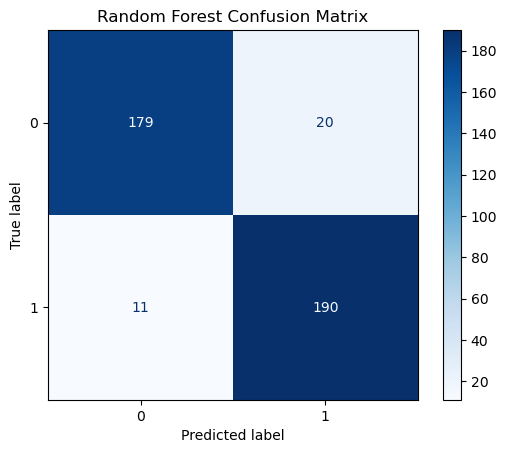

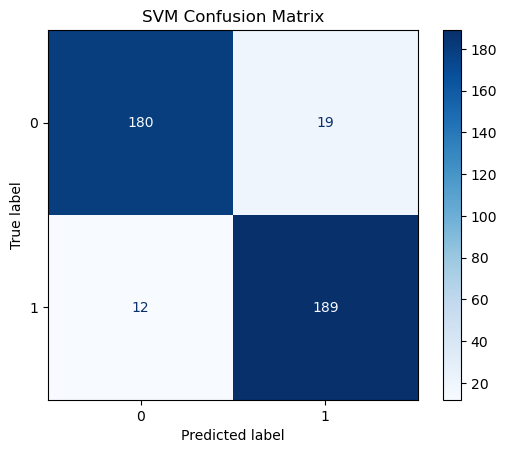

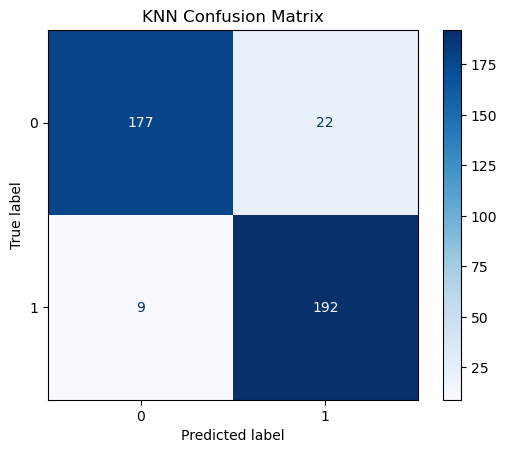

In [35]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

## Hasil Akurasi Eksperimen 2

Pada Eksperimen 1, HE merusak tekstur karena menaikkan kontras secara global secara berlebihan (over-saturation). Di Eksperimen 2, digunakan CLAHE (Contrast Limited Adaptive Histogram Equalization). CLAHE membagi citra daging menjadi beberapa ubin kecil (tiles) dan melakukan ekualisasi kontras secara lokal. Yang paling penting, CLAHE membatasi lonjakan kontras (contrast limiting). Dampaknya, pola serat daging dan marbling lemak diperjelas secara proporsional tanpa merusak detail tekstur mikronya. Fitur GLCM yang diekstrak pun menjadi jauh lebih representatif.

Gaussian blur di Eksperimen 1 membuat tepi serat daging menjadi buram (smearing effect). Di Eksperimen 2, Median Blur bekerja dengan mengganti nilai piksel dengan nilai median dari tetangganya. Sifat utama dari Median Blur adalah mampu menghilangkan noise (seperti bintik-bintik halus) namun tetap mempertahankan ketajaman tepi objek (edge-preserving). Dampaknya, batas serat daging dan lemak tetap tajam (tidak blur), tetapi bintik noise yang mengganggu GLCM berhasil disaring dengan bersih.

Pada Eksperimen 2 ini, diperoleh hasil akurasi yang sama persis untuk setiap model. Hal ini mungkin terjadi karena tahap preprocessing CLAHE + Median Blur telah berhasil mereduksi dimensi informasi pada citra hingga menyisakan pola yang sangat solid. Ketiga model machine learning tersebut menemui batas optimal yang sama karena informasi yang disediakan oleh fitur GLCM pada eksperimen ini memang hanya mampu mengklasifikasikan kelas daging hingga tingkat akurasi tersebut.

In [36]:
results_eksperimen2 = {
    'Model': ['Random Forest', 'SVM', 'KNN'],
    'Akurasi (%)': [
        accuracy_score(y_test, rf.predict(X_test)) * 100,
        accuracy_score(y_test, svm.predict(X_test)) * 100,
        accuracy_score(y_test, knn.predict(X_test)) * 100,
    ]
}
df_results2 = pd.DataFrame(results_eksperimen2)
df_results2['Akurasi (%)'] = df_results2['Akurasi (%)'].map(lambda x: f"{x:.2f}")
print("=== Hasil Akurasi Eksperimen 2 (CLAHE + Median Blur) ===")
display(df_results2)

=== Hasil Akurasi Eksperimen 2 (CLAHE + Median Blur) ===


,Model,Akurasi (%)
0,Random Forest,92.25
1,SVM,92.25
2,KNN,92.25
